EDAの結果、モデリングに使用する可能性のあるセンサーは以下
<br>一軍 42,41,39,4
<br>二軍 38,43,7,6
<br>三軍 8
<br>四軍 40,5

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [6]:
data_dir = Path('../data/raw/')
df = pd.read_csv(data_dir/'sensor.csv')

まずはsensor_04に絞って、モデリングを行う。
<br>まず前処理をする。

In [7]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [11]:
b = df['sensor_04'].isnull()
null_idx = df[b].index
null_idx

Index([ 25112,  38508,  38509,  38510,  38511,  38512,  38513,  38514,  38515,
       134855, 134873, 136197, 136265, 145992, 145993, 145994, 220008, 220009,
       220010],
      dtype='int64')

欠損地は非常に少なく、またbroken_idxとも関係がなさそうなので、シンプルに線形補完を行う。（ARIMAは等間隔の時系列を前提とするから、欠損行を削除するのは、時系列に穴を作ってしまい、モデルが誤作動する可能性がある）

In [12]:
df = df.set_index('timestamp')

In [ ]:
df.head()

,Unnamed: 0,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,...,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51,machine_status
timestamp,,,,,,,,,,,,,,,,,,,,,
2018-04-01 00:00:00,0,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,15.56713,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
2018-04-01 00:01:00,1,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,15.56713,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
2018-04-01 00:02:00,2,2.444734,47.35243,53.2118,46.397570,638.8889,73.54598,13.32465,16.03733,15.61777,...,41.66666,39.351852,65.39352,51.21528,38.194443,155.9606,67.12963,241.3194,203.7037,NORMAL
2018-04-01 00:03:00,3,2.460474,47.09201,53.1684,46.397568,628.1250,76.98898,13.31742,16.24711,15.69734,...,40.88541,39.062500,64.81481,51.21528,38.194440,155.9606,66.84028,240.4514,203.1250,NORMAL
2018-04-01 00:04:00,4,2.445718,47.13541,53.2118,46.397568,636.4583,76.58897,13.35359,16.21094,15.69734,...,41.40625,38.773150,65.10416,51.79398,38.773150,158.2755,66.55093,242.1875,201.3889,NORMAL


In [14]:
df = df.drop(columns = ['Unnamed: 0'])

In [16]:
df.head(3)

,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,sensor_09,...,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51,machine_status
timestamp,,,,,,,,,,,,,,,,,,,,,
2018-04-01 00:00:00,2.465394,47.09201,53.2118,46.31076,634.3750,76.45975,13.41146,16.13136,15.56713,15.05353,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
2018-04-01 00:01:00,2.465394,47.09201,53.2118,46.31076,634.3750,76.45975,13.41146,16.13136,15.56713,15.05353,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
2018-04-01 00:02:00,2.444734,47.35243,53.2118,46.39757,638.8889,73.54598,13.32465,16.03733,15.61777,15.01013,...,41.66666,39.351852,65.39352,51.21528,38.194443,155.9606,67.12963,241.3194,203.7037,NORMAL


In [22]:
s04 = df['sensor_04'].interpolate(method='linear')
s04.isnull().sum()

np.int64(0)

STL分解を始める前に周期periodを決定したい。
<br>そこでACF（自己相関関数）を用いて最初の1週間について計算してみる

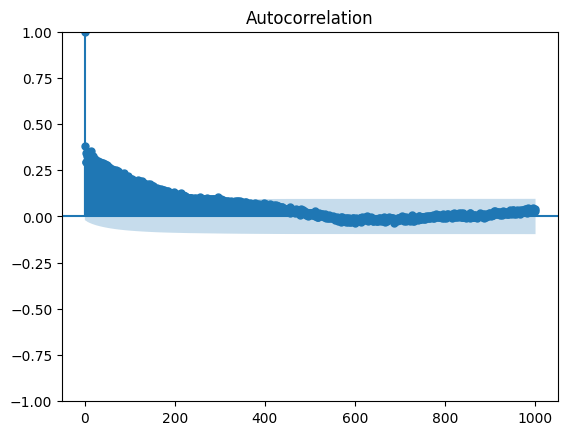

In [31]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(s04[:10080], lags=1000)  # 2日分のラグまで確認
plt.show()

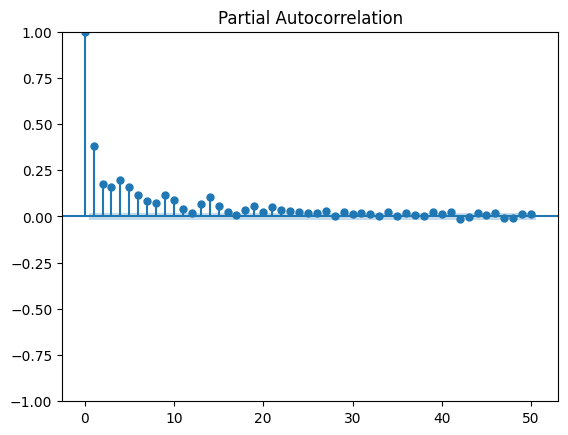

In [27]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(s04[:10080], lags = 50)
plt.show()

ACFは、t=1以降なだらかに降下傾向で
<br>PACFはt=1の後に、急に値が落ちていることから、
<br>s04はAR(1)の可能性が高い。

In [32]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(s04)
print(f'ADF統計量: {result[0]:.4f}')
print(f'p値: {result[1]:.4f}')


ADF統計量: -6.5605
p値: 0.0000


p < 0.05より、s04は定常
よってARIMA(1, 0, 0)を適用する。

In [34]:
s04_normal = s04[df['machine_status'] == 'NORMAL']

In [38]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(s04_normal, order = (1, 0, 0))
model.fit()

print(model.fit().params)
print(model.fit().pvalues)

/opt/anaconda3/envs/p2-anomaly/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/p2-anomaly/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/p2-anomaly/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


const     625.673568
ar.L1       0.985989
sigma2     71.869043
dtype: float64
const     0.0
ar.L1     0.0
sigma2    0.0
dtype: float64


ARIMA(1,0,0)が正しいことがわかった
<br>数式で書くと y(t) = 625.67 + 0.986 * y(t-1) +　ε(t)

In [39]:
full_result = model.fit().apply(s04)
residuals = full_result.resid

/opt/anaconda3/envs/p2-anomaly/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/p2-anomaly/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/p2-anomaly/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency min will be used.
  self._init_dates(dates, freq)


<Figure size 640x480 with 0 Axes>

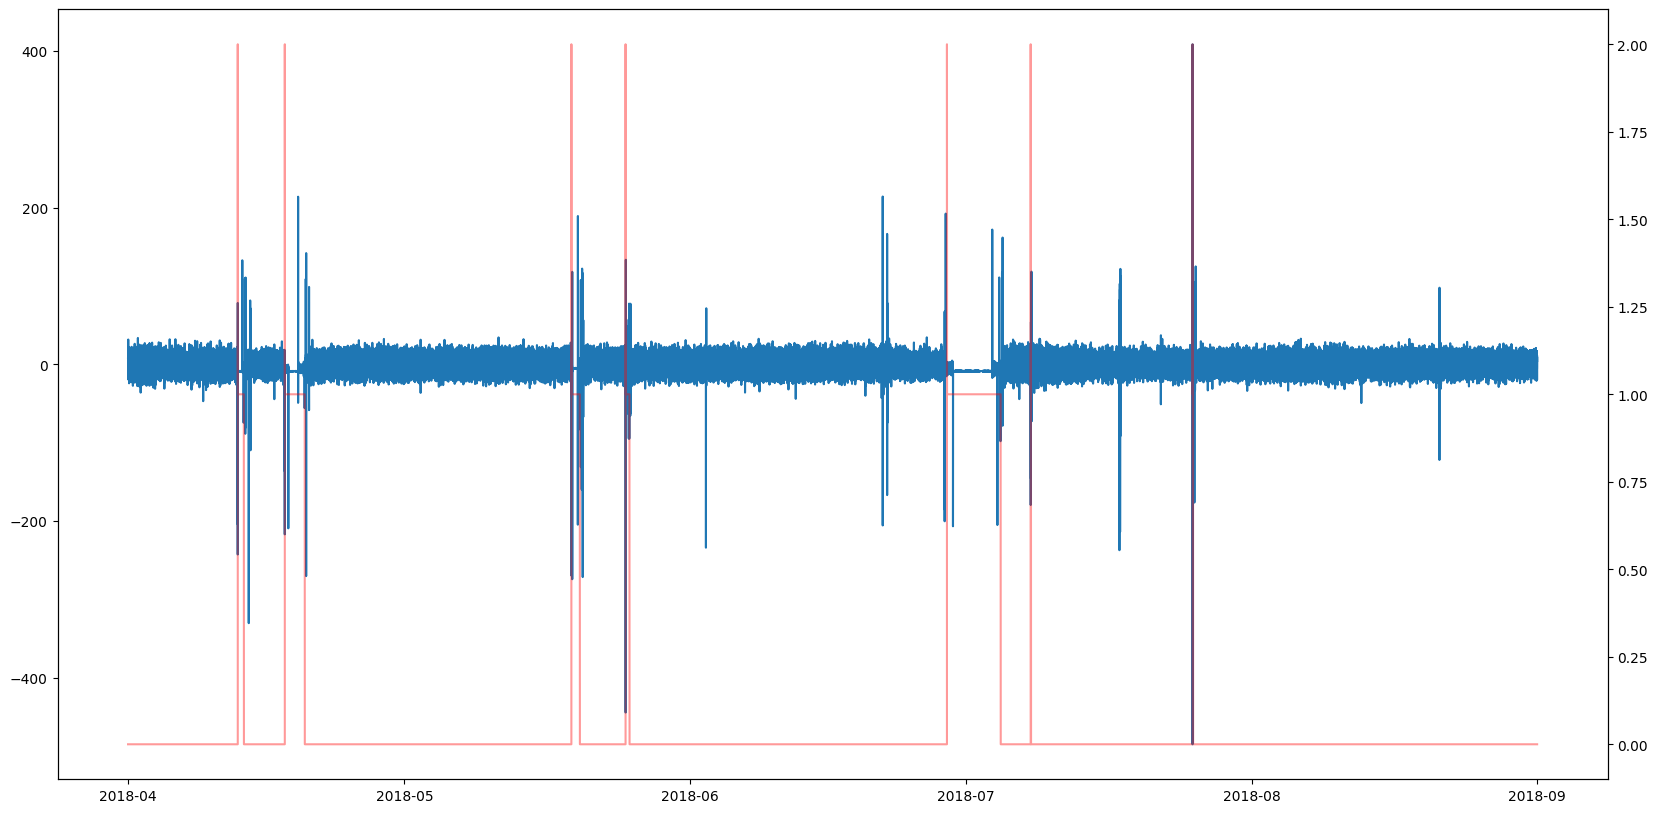

In [44]:
status_to_number = {'NORMAL':0, 'RECOVERING':1, 'BROKEN':2}
df['status_num'] = df['machine_status'].map(status_to_number)

plt.figure()
fig, ax1 = plt.subplots(figsize = (20,10))
ax1.plot(df.index, residuals)

ax2 = ax1.twinx()
ax2.plot(df.index,df['status_num'], alpha = 0.4, color = 'red')

plt.show()

s04_normalで学習済みのモデルをs04の全データに適用してみたところ、
<br>BROKEN時に残差が大きくなり、RECOVERINGの時に残差が小さくなることが確認された
<br>しかし、BROKENじゃない時にも、残差が大きくなっている瞬間もある。

次は、残差に閾値を設けて定量評価してみる。

- signal_a：residualsの標準偏差＊???の閾値を設けて、それより大きい残差のインデックスを取得<br>
    →主に'BROKEN'を狙う
- signal_b：residualsの標準偏差＊???の閾値を設けて、それより小さい残差のインデックスを取得<br>
    →主に、'RECOVERING'を狙う。先ほどの目視の観察から、'RECOVERING'のインデックスと被ったresidualsの値は、'NORMAL'の領域よりも異常に小さい変動を見せていたことから。

それぞれの閾値の倍率は実験して、目視で調整

In [50]:
resid_normal = residuals[df['machine_status'] == 'NORMAL']
resid_normal_std = resid_normal.std()
resid_normal_std

np.float64(8.367403268828603)

In [119]:
threshold = 20*resid_normal_std
signal_a = residuals.abs() > threshold
residuals[signal_a].count()

np.int64(33)

In [112]:
rolling_std = residuals.rolling(window=30).std()
signal_b = rolling_std < (resid_normal_std * 0.35)
residuals[signal_b].count()

np.int64(14314)

In [85]:
df['machine_status'].value_counts()

machine_status
NORMAL        205836
RECOVERING     14477
BROKEN             7
Name: count, dtype: int64

<Figure size 640x480 with 0 Axes>

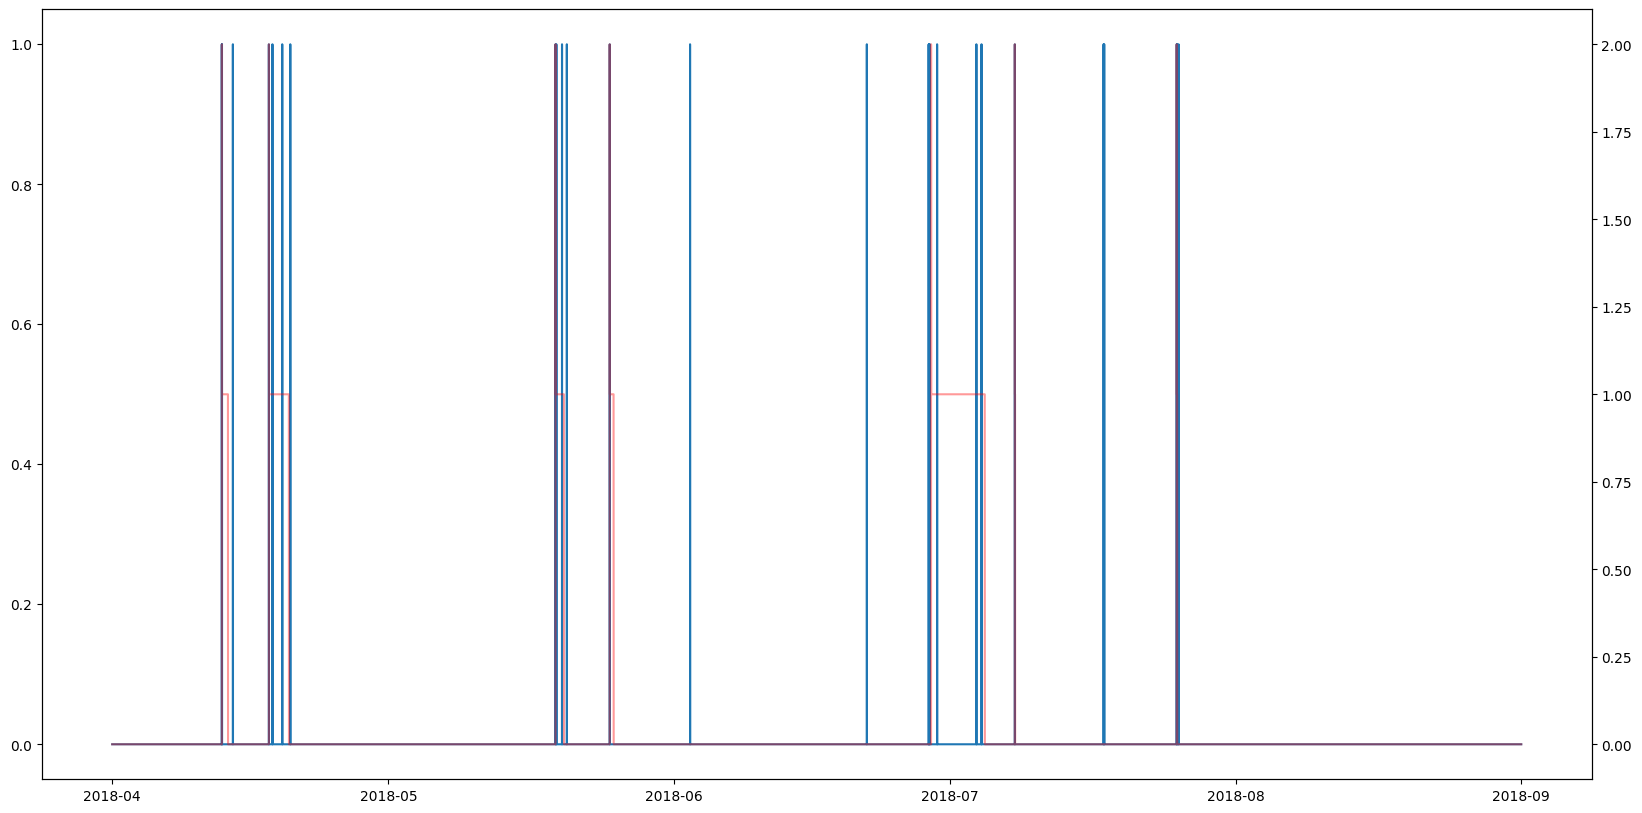

<Figure size 640x480 with 0 Axes>

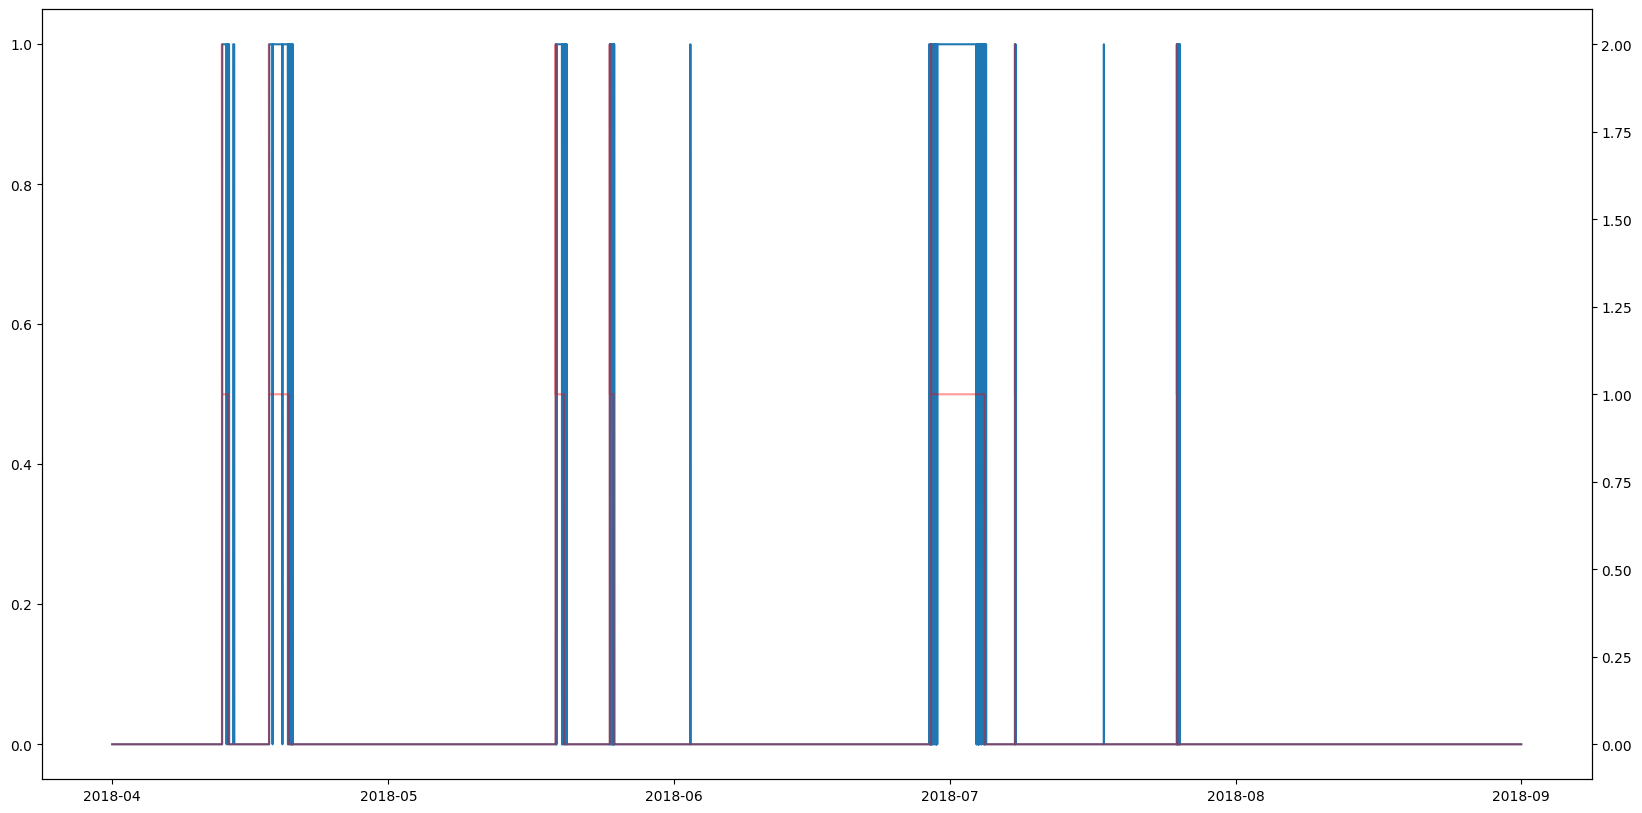

In [120]:
int_signal_a = signal_a.astype(int)
int_signal_b = signal_b.astype(int)

plt.figure()
fig, ax1 = plt.subplots(figsize = (20,10))
ax1.plot(df.index, int_signal_a)
ax2 = ax1.twinx()
ax2.plot(df.index, df['status_num'], alpha = 0.4, color = 'red')
plt.show()

plt.figure()
fig, ax1 = plt.subplots(figsize = (20,10))
ax1.plot(df.index, int_signal_b)
ax2 = ax1.twinx()
ax2.plot(df.index, df['status_num'], alpha = 0.4, color = 'red')
plt.show()


In [116]:
anomaly_bool = signal_a|signal_b

from sklearn.metrics import classification_report
y_true = (df['machine_status'] != 'NORMAL').astype(int)
y_pred = anomaly_bool.astype(int)

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99    205836
           1       0.89      0.89      0.89     14484

    accuracy                           0.99    220320
   macro avg       0.94      0.94      0.94    220320
weighted avg       0.99      0.99      0.99    220320



0が'NORMAL', 1が'BROKEN', 'RECOVERING'についての結果なのですが、
- 0の結果については、そもそもnormalとそれ以外でデータ数が非常に不均衡なので、99%になって当たり前。重要ではない。
- 重要なのは1の結果で
    - precision(予測したもののうち、正解のものの割合) = 89%
    - recall(正解のもののうち、予測できたものの割合) = 89%

<br>ということで、悪くも良くもない結果かな